In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
df= pd.read_csv(r"C:\Users\hi\OneDrive\Documents\Working\dataset\IMDB Dataset.csv")

In [4]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [6]:
df.shape

(50000, 2)

In [7]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [8]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(418)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df['sentiment'].value_counts()

sentiment
positive    24884
negative    24698
Name: count, dtype: int64

In [12]:
import matplotlib.pyplot as plt

In [13]:
import seaborn as sns

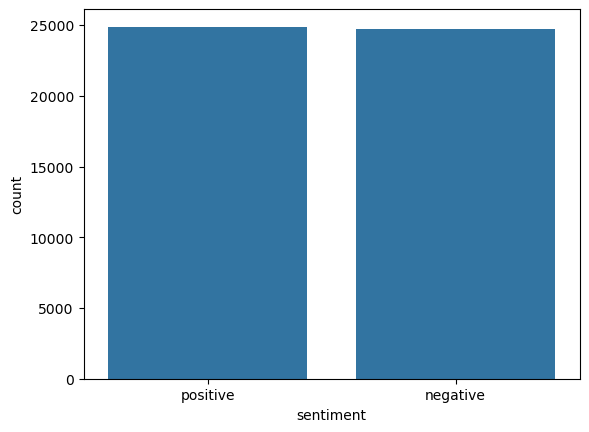

In [14]:
sns.countplot(x='sentiment', data=df)
plt.show()

In [15]:
import nltk

In [16]:
from nltk.corpus import stopwords

In [17]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [18]:
import re

In [19]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

In [20]:
df['clean_review'] = df['review'].apply(clean_text)

In [21]:
df['sentiment'] = df['sentiment'].map({
    'positive':1,
    'negative':0
})

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [23]:
tfidf = TfidfVectorizer(
    max_features=10000
)

In [24]:
X = tfidf.fit_transform(df['clean_review'])
y = df['sentiment']

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
from sklearn.linear_model import LogisticRegression

In [28]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [30]:
print("Accuracy:",
      accuracy_score(y_test, lr_pred))
print("Precision:",
      precision_score(y_test, lr_pred))
print("Recall:",
      recall_score(y_test, lr_pred))
print("F1 Score:",
      f1_score(y_test, lr_pred))

Accuracy: 0.8932136734899667
Precision: 0.8824907280890103
Recall: 0.9081960626757734
F1 Score: 0.8951588951588951


In [31]:
cm = confusion_matrix(y_test, lr_pred)

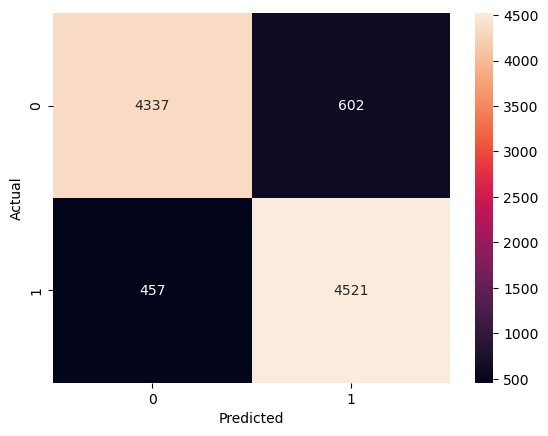

In [32]:
sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [33]:
print(classification_report(
    y_test,
    lr_pred
))

              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4939
           1       0.88      0.91      0.90      4978

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



In [34]:
prob = lr.predict_proba(X_test)[:,1]
roc_score = roc_auc_score(
    y_test,
    prob
)
print("ROC AUC:", roc_score)

ROC AUC: 0.9587812208908506


In [35]:
fpr, tpr, threshold = roc_curve(
    y_test,
    prob
)

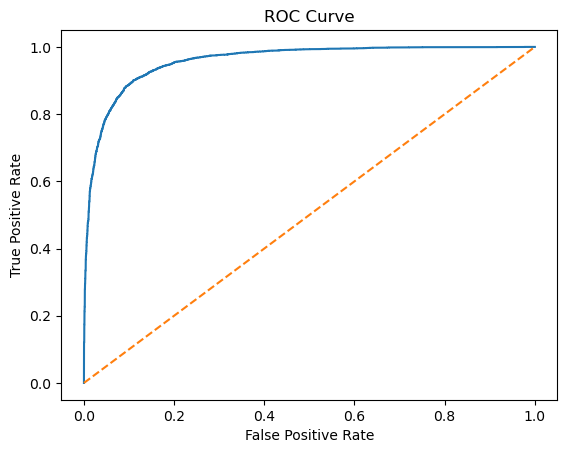

In [36]:
plt.plot(fpr, tpr)
plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [37]:
from sklearn.ensemble import RandomForestClassifier

In [38]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [ ]:
rf.fit(X_train, y_train)

In [ ]:
rf_pred = rf.predict(X_test)

In [ ]:
print(
    "RF Accuracy:",
    accuracy_score(y_test, rf_pred)
)

In [ ]:
from sklearn.naive_bayes import MultinomialNB

In [ ]:
nb = MultinomialNB()

In [ ]:
nb.fit(X_train, y_train)

In [ ]:
nb_pred = nb.predict(X_test)

In [ ]:
print(
    "NB Accuracy:",
    accuracy_score(y_test, nb_pred)
)

In [ ]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Naive Bayes"
    ],
    "Accuracy":[
        accuracy_score(y_test, lr_pred),

        accuracy_score(y_test, rf_pred),

        accuracy_score(y_test, nb_pred)
    ]
})
results

In [ ]:
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1,2)
)